In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
auto = pd.read_csv('Automobile_data.csv')

In [3]:
auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [4]:
auto.shape

(205, 26)

In [5]:
auto.dtypes

symboling              int64
normalized-losses        str
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object

In [6]:
auto.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


In [7]:
#Six columns are hiding missing values as the string "?" instead of true NaN, which is why they're showing as text type instead of numeric.
#First step is converting those placeholders to real NaN so we can see the true scope of missingness, then decide how to handle each column.

auto = auto.replace('?', np.nan)

In [8]:
auto.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [9]:
#Dropping normalized-losses entirely (41 missing, ~20% of rows) since it's an insurance risk-adjustment figure tangential to the price/spec analysis this project focuses on, and imputing that much of a column would introduce more bias than it's worth. 
#The remaining columns each have only 2-4 missing values, so those rows can be safely dropped without meaningful data loss.

auto = auto.drop(columns='normalized-losses')

In [11]:
auto = auto.dropna(axis=0)
auto.shape

(193, 25)

In [12]:
#Converting the columns that were previously hiding ? values (bore, stroke, horsepower, peak-rpm, price) to proper numeric type.
auto['bore'] = pd.to_numeric(auto['bore'])
auto['stroke'] = pd.to_numeric(auto['stroke'])
auto['horsepower'] = pd.to_numeric(auto['horsepower'])
auto['peak-rpm'] = pd.to_numeric(auto['peak-rpm'])
auto['price'] = pd.to_numeric(auto['price'])

In [13]:
auto.dtypes

symboling              int64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object

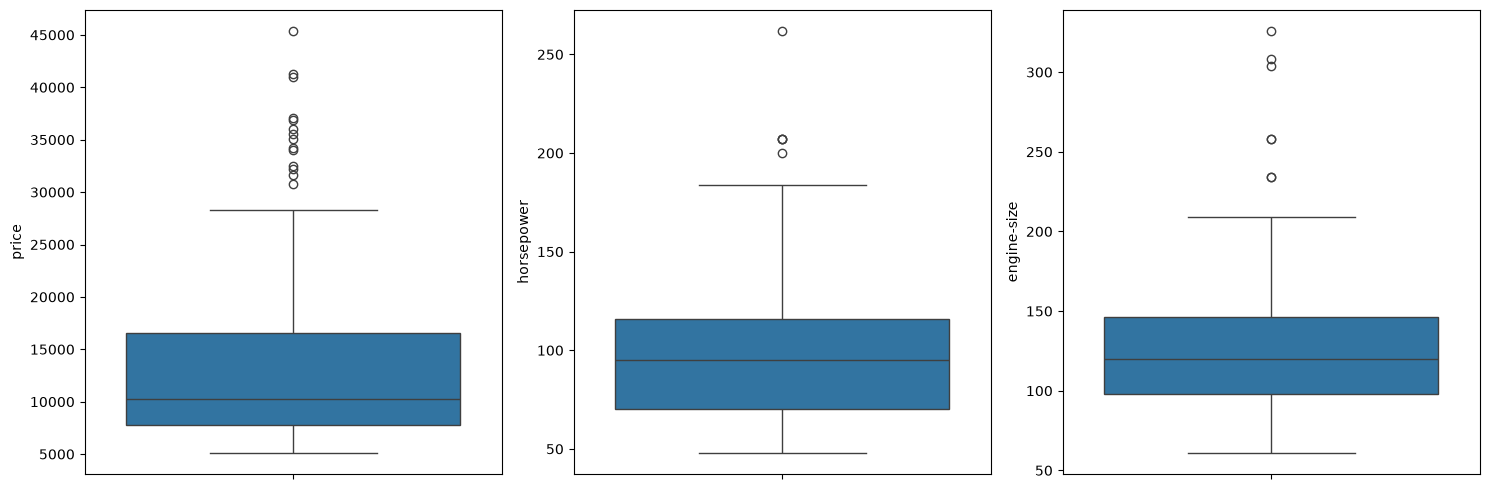

In [15]:
#Checking for outliers in the key numeric variables most relevant to price analysis — price itself, horsepower, and engine-size — 
# using boxplots first, then the IQR method to get exact counts and bounds, 
# same approach used in the Heart Disease project.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=auto['price'], ax=axes[0])
sns.boxplot(y=auto['horsepower'], ax=axes[1])
sns.boxplot(y=auto['engine-size'], ax=axes[2])
plt.tight_layout()
plt.show()

In [ ]:
#Getting exact outlier counts and bounds using the IQR method, then checking whether the high-price, high-horsepower, and high-engine-size.
#outliers are the same vehicles (which would suggest they're consistently premium/performance cars) or different ones (which would be a more surprising, disconnected pattern).

def find_outliers_iqr(col):
    Q1 = auto[col].quantile(0.25)
    Q3 = auto[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = auto[(auto[col] < lower) | (auto[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.1f} to {upper:.1f})")
    return outliers

price_outliers = find_outliers_iqr('price')
print(price_outliers[['make', 'price', 'horsepower', 'engine-size']])
print()

hp_outliers = find_outliers_iqr('horsepower')
print(hp_outliers[['make', 'price', 'horsepower', 'engine-size']])
print()

engine_size_outliers = find_outliers_iqr('engine-size')
print(engine_size_outliers[['make', 'price', 'horsepower', 'engine-size']])

price: 14 outliers (bounds: -5427.5 to 29680.5)
              make  price  horsepower  engine-size
15             bmw  30760         182          209
16             bmw  41315         182          209
17             bmw  36880         182          209
47          jaguar  32250         176          258
48          jaguar  35550         176          258
49          jaguar  36000         262          326
70   mercedes-benz  31600         123          183
71   mercedes-benz  34184         155          234
72   mercedes-benz  35056         155          234
73   mercedes-benz  40960         184          308
74   mercedes-benz  45400         184          304
126        porsche  32528         207          194
127        porsche  34028         207          194
128        porsche  37028         207          194

horsepower: 5 outliers (bounds: 1.0 to 185.0)
        make  price  horsepower  engine-size
49    jaguar  36000         262          326
105   nissan  19699         200          181
126  

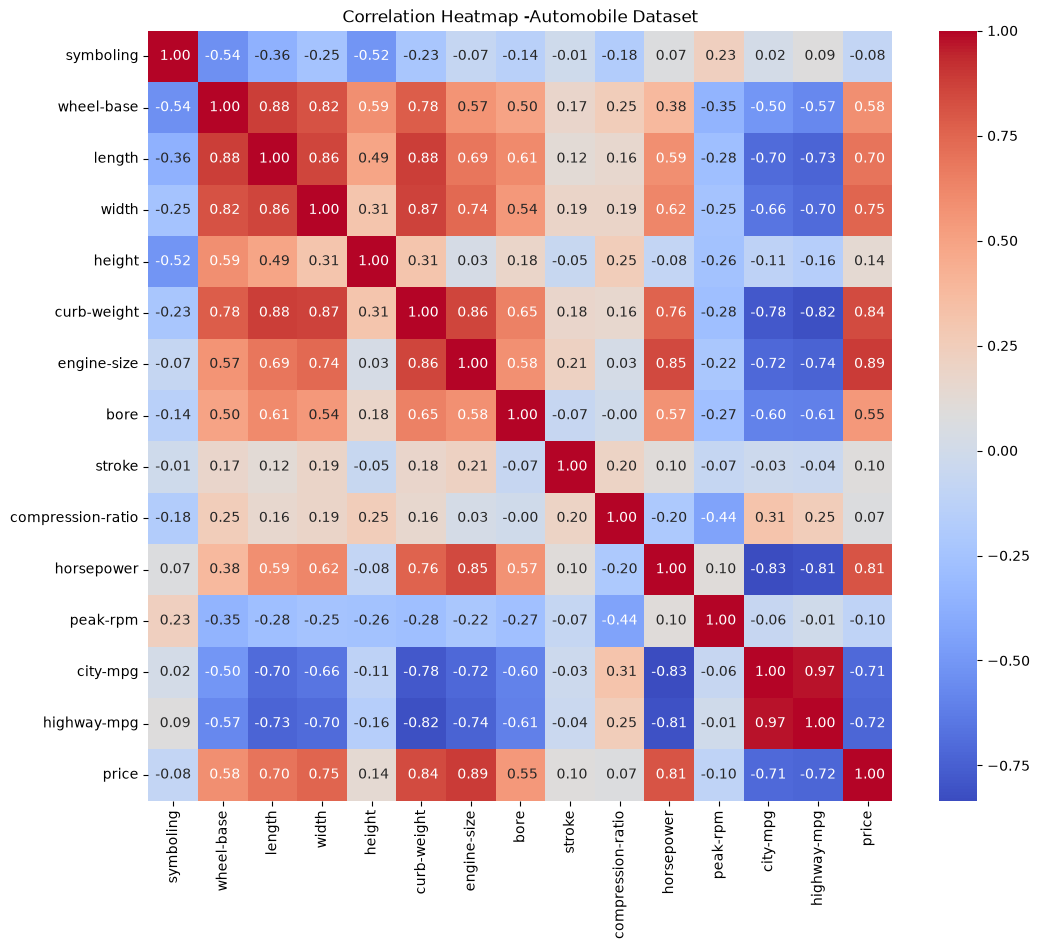

In [24]:
#All three sets of outliers (price, horsepower, engine-size) trace back to genuine luxury/performance brands rather than data errors, so all outliers are retained.
#This mirrors the reasoning from the Heart Disease project — outliers are only removed if they represent errors, not real extreme values.

plt.figure(figsize=(12, 10))
corr = auto.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=' .2f', cmap='coolwarm')
plt.title('Correlation Heatmap -Automobile Dataset')
plt.show()

In [25]:
price_corr = corr['price'].sort_values(ascending=False)
print(price_corr)

price                1.000000
engine-size          0.888778
curb-weight          0.835368
horsepower           0.812453
width                0.754649
length               0.695928
wheel-base           0.584951
bore                 0.546295
height               0.136234
stroke               0.096007
compression-ratio    0.074483
symboling           -0.084835
peak-rpm            -0.103835
city-mpg            -0.706618
highway-mpg         -0.719178
Name: price, dtype: float64


In [26]:
#Comparing average price across categorical variables (make, body-style, fuel-type) to see which categories command a price premium — same approach as the gender/chest-pain breakdown in the Heart Disease project.

print(auto.groupby('make')['price'].mean().sort_values(ascending=False))

make
jaguar           34600.000000
mercedes-benz    33647.000000
porsche          31400.500000
bmw              26118.750000
volvo            18063.181818
audi             17859.166667
mercury          16503.000000
alfa-romero      15498.333333
peugot           15489.090909
saab             15223.333333
nissan           10415.666667
volkswagen       10077.500000
toyota            9885.812500
mazda             9852.000000
mitsubishi        9239.769231
isuzu             8916.500000
subaru            8541.250000
honda             8184.692308
plymouth          7963.428571
dodge             7790.125000
chevrolet         6007.000000
Name: price, dtype: float64


In [27]:
print(auto.groupby('body-style')['price'].mean().sort_values(ascending=False))
print(auto.groupby('fuel-type')['price'].mean().sort_values(ascending=False))

body-style
hardtop        22208.500000
convertible    21890.500000
sedan          14563.739130
wagon          12500.166667
hatchback       9763.984127
Name: price, dtype: float64
fuel-type
diesel    16103.578947
gas       12977.252874
Name: price, dtype: float64


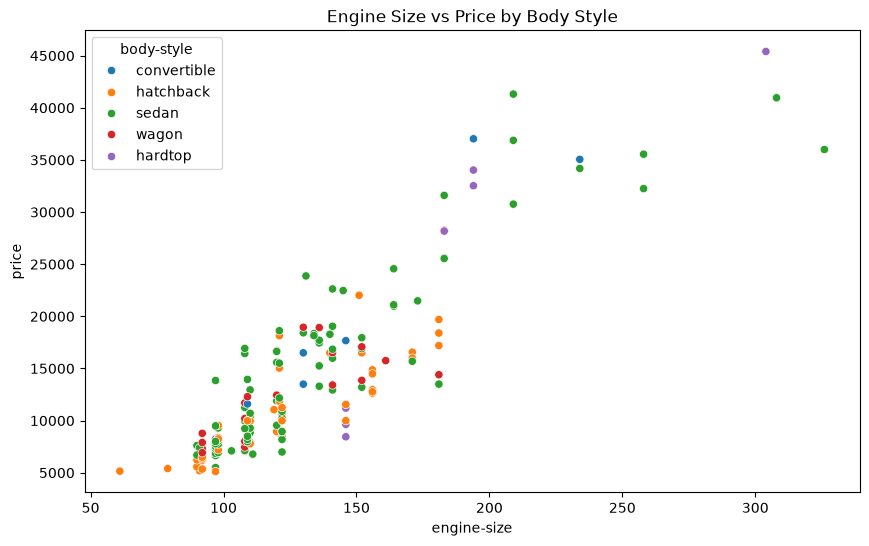

In [28]:
#Checking whether the price-vs-engine-size relationship holds across body styles, or whether it's mainly driven by the handful of luxury brand outliers identified earlier.
#this confirms whether "bigger engine = higher price" is a general rule or a luxury-brand-specific pattern.

plt.figure(figsize=(10,6))
sns.scatterplot(data=auto, x='engine-size', y='price', hue='body-style')
plt.title('Engine Size vs Price by Body Style')
plt.show()

In [29]:
# Final check before export
print(auto.isnull().sum().sum())
print(auto.dtypes)

auto.to_csv('automobile_cleaned.csv', index=False)

0
symboling              int64
make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object
